#Task 3: Country-Wise Netflix Content Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#import dataset
df=pd.read_csv(r"netflix_cleaned.csv")
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [3]:
#check shape of dataset
df.shape

(8790, 10)

In [4]:
#Step 1: Extract and clean country information

df["country"].head(20)

0      United States
1             France
2      United States
3             Brazil
4      United States
5     United Kingdom
6      United States
7              India
8            Germany
9              India
10             India
11             India
12          Pakistan
13     United States
14     United States
15     United States
16     United States
17          Pakistan
18          Pakistan
19     United States
Name: country, dtype: object

In [5]:
#Check the data type
print(df["country"].dtype)

object


In [6]:
#check if country contains missing values
print("Missing country values:", df["country"].isna().sum())

Missing country values: 0


In [7]:
#Check unique country entries
print("Unique country entries:", df["country"].nunique())

Unique country entries: 86


In [32]:
# STEP 2: CALCULATE CONTENT COUNT BY COUNTRY

# Split multiple countries in each cell
country_data = (df["country"].str.split(",").explode().str.strip())

# Check the result
print("Individual country values:")
print(country_data.head(20))

Individual country values:
0      United States
1             France
2      United States
3             Brazil
4      United States
5     United Kingdom
6      United States
7              India
8            Germany
9              India
10             India
11             India
12          Pakistan
13     United States
14     United States
15     United States
16     United States
17          Pakistan
18          Pakistan
19     United States
Name: country, dtype: object


In [34]:
# Count how many titles are associated with each country

country_counts = country_data.value_counts()
print("Top 20 countries by content count:")
print(country_counts.head(20))

Top 20 countries by content count:
country
United States     3240
India             1057
United Kingdom     638
Pakistan           421
Not Given          287
Canada             271
Japan              259
South Korea        214
France             213
Spain              182
Mexico             138
Egypt              123
Australia          114
Turkey             112
Nigeria            105
Germany            104
China              100
Brazil              88
Taiwan              86
Indonesia           86
Name: count, dtype: int64


In [35]:
# Convert the Series into a DataFrame

country_df = country_counts.reset_index()

# Rename the columns
country_df.columns = ["Country", "Content_Count"]

print("Country-wise content count:")
print(country_df.head(20))

Country-wise content count:
           Country  Content_Count
0    United States           3240
1            India           1057
2   United Kingdom            638
3         Pakistan            421
4        Not Given            287
5           Canada            271
6            Japan            259
7      South Korea            214
8           France            213
9            Spain            182
10          Mexico            138
11           Egypt            123
12       Australia            114
13          Turkey            112
14         Nigeria            105
15         Germany            104
16           China            100
17          Brazil             88
18          Taiwan             86
19       Indonesia             86


In [36]:
#Check the total number of countries
print("Total number of countries:", len(country_df))

Total number of countries: 86


In [49]:
# STEP 3: IDENTIFY TOP 10 CONTENT-PRODUCING COUNTRIES

# Remove "Not Given" from the country analysis
country_analysis = country_df[country_df["Country"] != "Not Given"].copy()

In [50]:
# Sort countries by content count
# Highest number of titles will appear first

country_analysis= country_analysis.sort_values(by="Content_Count",ascending=False)

In [52]:
#Select the Top 10 countries
top_10_countries = country_analysis.head(10).copy()

# Step 3.4: Add ranking
top_10_countries["Rank"] = range(1, 11)

In [53]:
# Step 3.5: Calculate percentage of total country-content associations
total_content = country_analysis["Content_Count"].sum()

top_10_countries["Percentage"] = (
    top_10_countries["Content_Count"] / total_content * 100).round(2)

# Step 3.6: Arrange columns in a clean order

top_10_countries=top_10_countries[["Rank","Country","Content_Count","Percentage"]]

# Step 3.7: Display the final Top 10 ranking
print("Top 10 Countries by Netflix Content:")
print(top_10_countries.to_string(index=False))

Top 10 Countries by Netflix Content:
 Rank        Country  Content_Count  Percentage
    1  United States           3240       38.10
    2          India           1057       12.43
    3 United Kingdom            638        7.50
    4       Pakistan            421        4.95
    5         Canada            271        3.19
    6          Japan            259        3.05
    7    South Korea            214        2.52
    8         France            213        2.50
    9          Spain            182        2.14
   10         Mexico            138        1.62


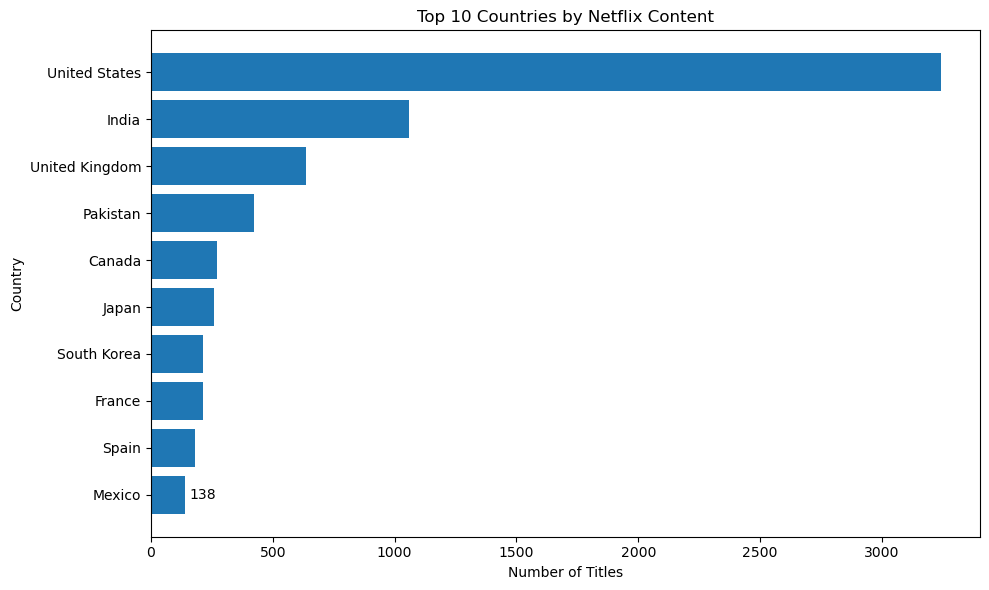

In [54]:
#Step 4: Create Visualization  and Rankings

#VISUALIZE TOP 10 COUNTRIES
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(10, 6))
# Create horizontal bar chart
bars = plt.barh(top_10_countries["Country"],top_10_countries["Content_Count"])
# Add title and labels
plt.title("Top 10 Countries by Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

# Display Rank 1 at the top
plt.gca().invert_yaxis()
# Add the exact count at the end of each bar
for bar in bars:
    value = bar.get_width()

plt.text(value +20,bar.get_y() + bar.get_height()/ 2,str(int(value)),va="center")
# Adjust spacing
plt.tight_layout()
# Display chart
plt.show()               

In [55]:
# Display a Clean Ranking Table

# TOP 10 COUNTRY RANKING TABLE
ranking_table = top_10_countries[["Rank","Country","Content_Count","Percentage"]]
print(ranking_table.to_string(index=False))

 Rank        Country  Content_Count  Percentage
    1  United States           3240       38.10
    2          India           1057       12.43
    3 United Kingdom            638        7.50
    4       Pakistan            421        4.95
    5         Canada            271        3.19
    6          Japan            259        3.05
    7    South Korea            214        2.52
    8         France            213        2.50
    9          Spain            182        2.14
   10         Mexico            138        1.62


In [56]:
#Step 5 — Generate Business Insights

# Get the country with the highest content count
top_country = top_10_countries.iloc[0]

print("Top content-producing country:")
print(top_country["Country"],"with",top_country["Content_Count"],"titles")

# Difference between #1 and #2
second_country = top_10_countries.iloc[1]

difference = (top_country["Content_Count"]- second_country["Content_Count"])
print("Difference between the top two countries:")
print(difference, "titles")

# Top 10 total content associations
top_10_total = top_10_countries["Content_Count"].sum()
print("Total content associations from Top 10 countries:")
print(top_10_total)

# Average content count among Top 10 countries
average_content = top_10_countries["Content_Count"].mean()
print("Average content count among Top 10 countries:")
print(round(average_content, 2))

Top content-producing country:
United States with 3240 titles
Difference between the top two countries:
2183 titles
Total content associations from Top 10 countries:
6633
Average content count among Top 10 countries:
663.3


## Key Insights

- The United States has the highest number of titles associated with
  it, with 3,240 titles.

- India ranks second with 1,057 titles.

- There is a difference of 2,183 titles between the United States
  and India in country-content associations.

- The Top 10 countries collectively account for 6,633
  country-content associations.

- The average content count among the Top 10 countries is 663.3.

- "Not Given" was excluded from the country ranking because it
  represents missing country information rather than an actual country.

- Since a title can be associated with multiple countries, these
  figures represent country-content associations rather than unique
  titles produced by each country.